In [2]:
import os

BASE_DIR = os.getcwd()
PLOT_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)
print("Plots will be saved in:", PLOT_DIR)


Plots will be saved in: c:\Users\Bharat Singh\Desktop\Alzheimers Prediction\notebook\plots


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,
    confusion_matrix, roc_curve, auc,
    classification_report, roc_auc_score
)


In [4]:
df = pd.read_csv("../data/alzheimers_disease_data.csv")

# Drop non-feature columns if present
drop_cols = [c for c in ["PatientID", "DoctorInCharge"] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)

print("Dataset shape :", df.shape)
print("Features      :", df.drop("Diagnosis", axis=1).columns.tolist())
print()
print("Class distribution (BEFORE undersampling):")
print(df["Diagnosis"].value_counts())
print(f"  → Class 0 (No AD) : {(df.Diagnosis==0).sum()}")
print(f"  → Class 1 (AD)    : {(df.Diagnosis==1).sum()}")
print(f"  → Imbalance ratio  : {(df.Diagnosis==0).sum() / (df.Diagnosis==1).sum():.2f}:1")


Dataset shape : (2149, 15)
Features      : ['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems', 'BMI', 'DietQuality', 'AlcoholConsumption', 'PhysicalActivity', 'SleepQuality', 'CholesterolHDL', 'CholesterolTotal', 'SystolicBP', 'Age']

Class distribution (BEFORE undersampling):
Diagnosis
0    1389
1     760
Name: count, dtype: int64
  → Class 0 (No AD) : 1389
  → Class 1 (AD)    : 760
  → Imbalance ratio  : 1.83:1


  UNDERSAMPLING SUMMARY
Class                       Before    After
----------------------------------------
No Alzheimer's (0)            1389      760
Alzheimer's    (1)             760      760
----------------------------------------
Total samples                 2149     1520
Balance ratio               1.83:1   1.00:1

Removed 629 majority samples
Balanced dataset ready: 1520 samples


C:\Users\Bharat Singh\AppData\Local\Temp\ipykernel_13672\3757493459.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Plot saved: c:\Users\Bharat Singh\Desktop\Alzheimers Prediction\notebook\plots\undersampling_comparison.png


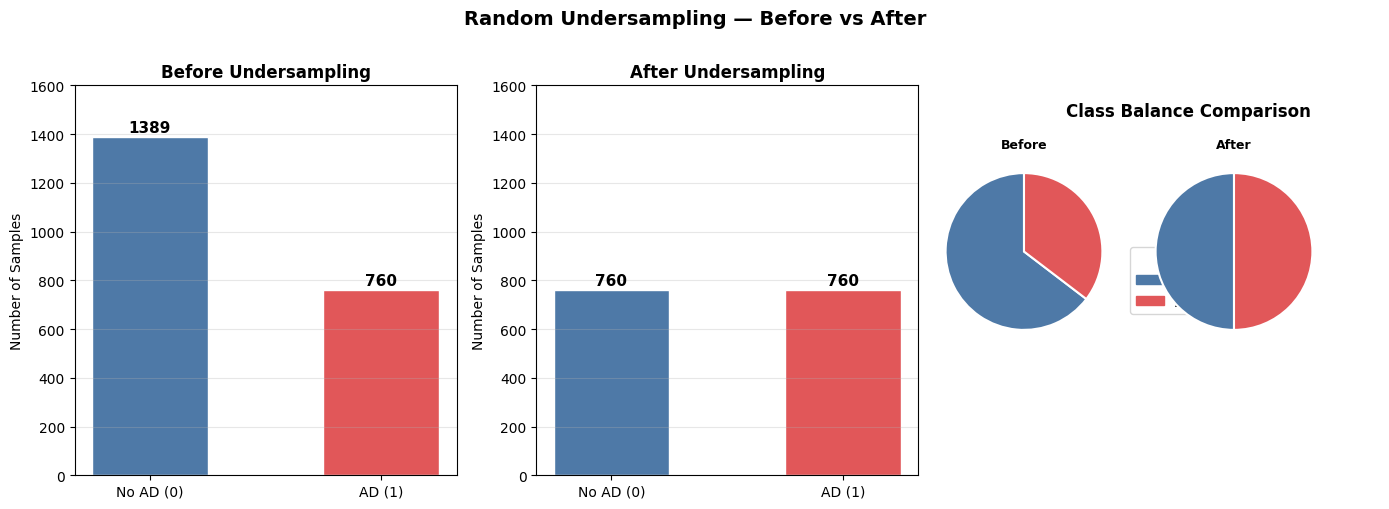

In [5]:
# ── Before undersampling ──────────────────────────────────────────────────────
before_counts = df["Diagnosis"].value_counts().sort_index()

# ── Apply Random Undersampling ────────────────────────────────────────────────
majority  = df[df.Diagnosis == 0]
minority  = df[df.Diagnosis == 1]

majority_down = resample(
    majority,
    replace=False,                   # without replacement
    n_samples=len(minority),         # match minority count
    random_state=42
)

df_bal = pd.concat([majority_down, minority]).sample(frac=1, random_state=42)

X = df_bal.drop("Diagnosis", axis=1)
y = df_bal["Diagnosis"]

# ── After undersampling ───────────────────────────────────────────────────────
after_counts = y.value_counts().sort_index()

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 40)
print("  UNDERSAMPLING SUMMARY")
print("=" * 40)
print(f"{'Class':<25} {'Before':>8} {'After':>8}")
print("-" * 40)
for cls in [0, 1]:
    label = "No Alzheimer's (0)" if cls == 0 else "Alzheimer's    (1)"
    print(f"{label:<25} {before_counts[cls]:>8} {after_counts[cls]:>8}")
print("-" * 40)
print(f"{'Total samples':<25} {before_counts.sum():>8} {after_counts.sum():>8}")
print(f"{'Balance ratio':<25} {'1.83:1':>8} {'1.00:1':>8}")
print("=" * 40)
print(f"\nRemoved {before_counts[0] - after_counts[0]} majority samples")
print(f"Balanced dataset ready: {len(df_bal)} samples")

# ── Visualise: Before vs After ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Plot 1: Before — bar chart
ax1 = axes[0]
colors_before = ["#4e79a7", "#e15759"]
bars1 = ax1.bar(["No AD (0)", "AD (1)"],
                [before_counts[0], before_counts[1]],
                color=colors_before, edgecolor="white", width=0.5)
ax1.set_title("Before Undersampling", fontsize=12, fontweight="bold")
ax1.set_ylabel("Number of Samples")
ax1.set_ylim(0, 1600)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(int(bar.get_height())), ha="center", fontsize=11, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# Plot 2: After — bar chart
ax2 = axes[1]
bars2 = ax2.bar(["No AD (0)", "AD (1)"],
                [after_counts[0], after_counts[1]],
                color=colors_before, edgecolor="white", width=0.5)
ax2.set_title("After Undersampling", fontsize=12, fontweight="bold")
ax2.set_ylabel("Number of Samples")
ax2.set_ylim(0, 1600)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(int(bar.get_height())), ha="center", fontsize=11, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

# Plot 3: Pie chart comparison (side by side using one pie each)
ax3 = axes[2]
ax3.axis("off")
# Draw two small pie charts manually as insets
ax_pie1 = fig.add_axes([0.665, 0.25, 0.14, 0.55])
ax_pie2 = fig.add_axes([0.815, 0.25, 0.14, 0.55])

ax_pie1.pie([before_counts[0], before_counts[1]],
            colors=colors_before, startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
ax_pie1.set_title("Before", fontsize=9, fontweight="bold", pad=4)

ax_pie2.pie([after_counts[0], after_counts[1]],
            colors=colors_before, startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
ax_pie2.set_title("After", fontsize=9, fontweight="bold", pad=4)

p1 = mpatches.Patch(color="#4e79a7", label="No AD (0)")
p2 = mpatches.Patch(color="#e15759", label="AD (1)")
ax3.legend(handles=[p1, p2], loc="center", fontsize=10, title="Class")
ax3.set_title("Class Balance Comparison", fontsize=12, fontweight="bold", x=0.5, y=0.9)

fig.suptitle("Random Undersampling — Before vs After", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_path = os.path.join(PLOT_DIR, "undersampling_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print("\nPlot saved:", save_path)
plt.show()
plt.close()


In [6]:
models = {
    "Logistic":     LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM":          SVC(probability=True, class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "XGB":          GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
}

test_sizes  = [0.2, 0.25, 0.3]

print("Models defined:")
for name in models:
    print(f"  - {name}")
print(f"\nTest sizes: {test_sizes}")


Models defined:
  - Logistic
  - SVM
  - DecisionTree
  - RandomForest
  - XGB

Test sizes: [0.2, 0.25, 0.3]



  TEST SIZE: 0.2
Train: 1216  |  Test: 304
  Logistic         Acc=0.8257  Rec=0.8750  F1=0.8339
  SVM              Acc=0.8520  Rec=0.9079  F1=0.8598
  DecisionTree     Acc=0.9211  Rec=0.9342  F1=0.9221
  RandomForest     Acc=0.9309  Rec=0.9342  F1=0.9311
  XGB              Acc=0.9178  Rec=0.9408  F1=0.9196


,Model,Accuracy,Recall,F1,Score
0,Logistic,0.825658,0.875000,0.833856,0.856083
1,SVM,0.851974,0.907895,0.859813,0.886310
2,DecisionTree,0.921053,0.934211,0.922078,0.929050
3,RandomForest,0.930921,0.934211,0.931148,0.932917
4,XGB,0.917763,0.940789,0.919614,0.931764


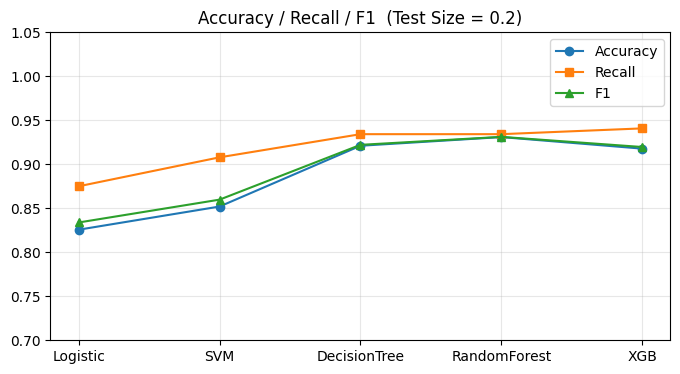

C:\Users\Bharat Singh\AppData\Local\Temp\ipykernel_13672\858478114.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=step_df, x="Model", y="Score", palette="viridis")


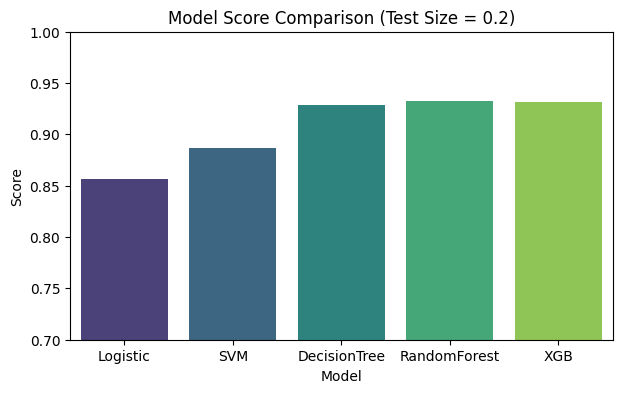

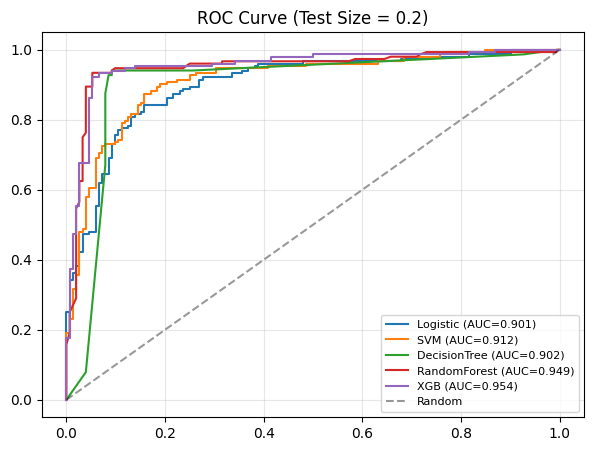

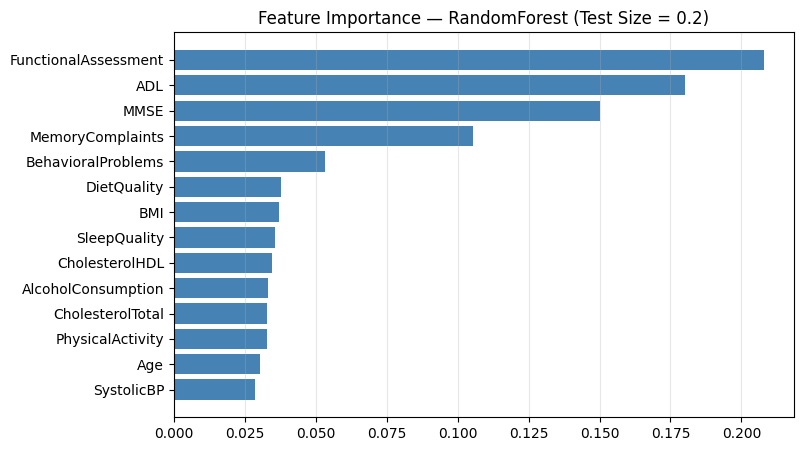


  TEST SIZE: 0.25
Train: 1140  |  Test: 380
  Logistic         Acc=0.8368  Rec=0.8684  F1=0.8418
  SVM              Acc=0.8474  Rec=0.8789  F1=0.8520
  DecisionTree     Acc=0.9342  Rec=0.9421  F1=0.9347
  RandomForest     Acc=0.9395  Rec=0.9368  F1=0.9393
  XGB              Acc=0.9395  Rec=0.9526  F1=0.9403


,Model,Accuracy,Recall,F1,Score
0,Logistic,0.836842,0.868421,0.841837,0.856289
1,SVM,0.847368,0.878947,0.852041,0.866783
2,DecisionTree,0.934211,0.942105,0.934726,0.938999
3,RandomForest,0.939474,0.936842,0.939314,0.937879
4,XGB,0.939474,0.952632,0.940260,0.947447


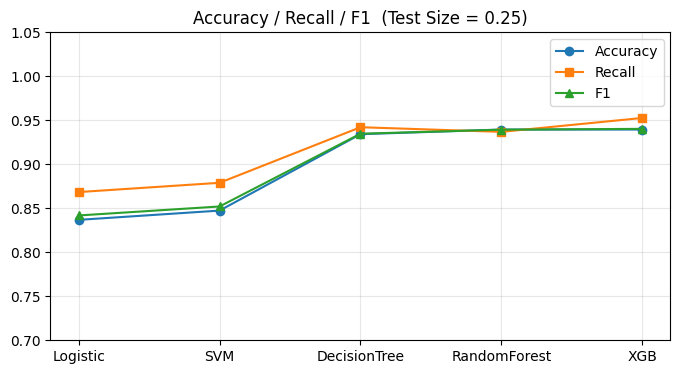

C:\Users\Bharat Singh\AppData\Local\Temp\ipykernel_13672\858478114.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=step_df, x="Model", y="Score", palette="viridis")


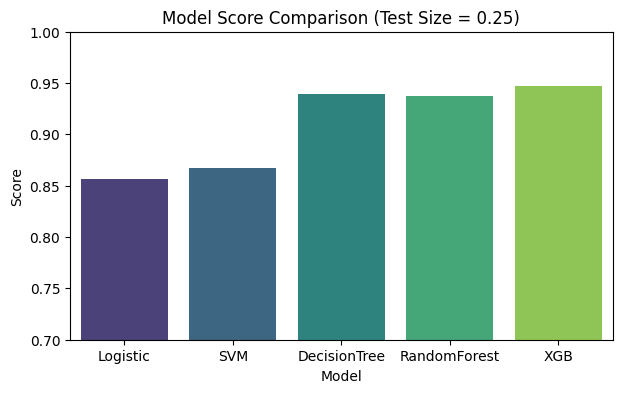

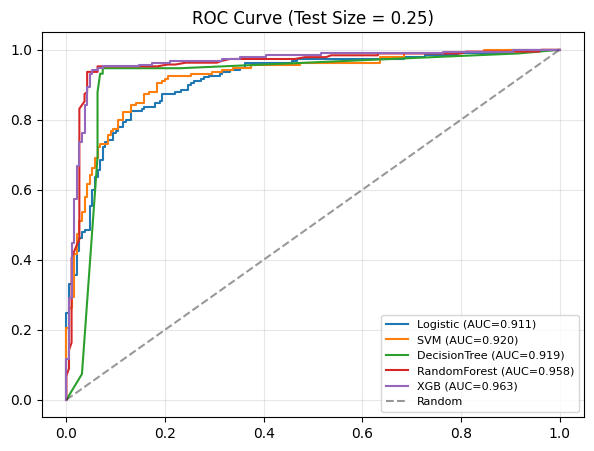

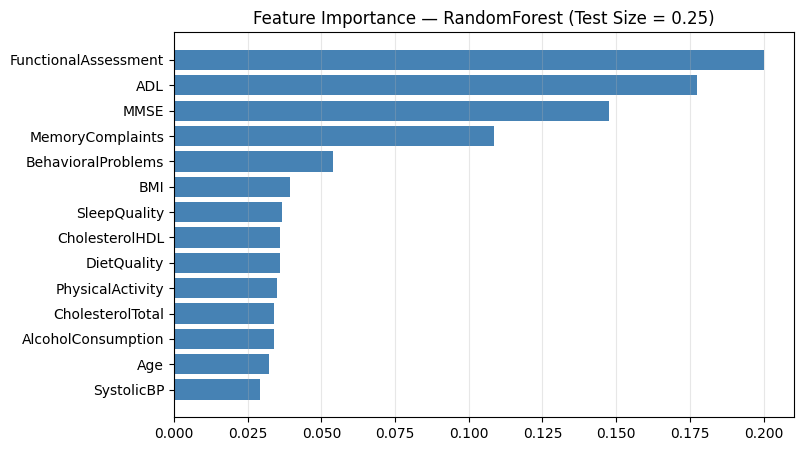


  TEST SIZE: 0.3
Train: 1064  |  Test: 456
  Logistic         Acc=0.8399  Rec=0.8553  F1=0.8423
  SVM              Acc=0.8596  Rec=0.8816  F1=0.8627
  DecisionTree     Acc=0.9386  Rec=0.9474  F1=0.9391
  RandomForest     Acc=0.9496  Rec=0.9518  F1=0.9497
  XGB              Acc=0.9408  Rec=0.9518  F1=0.9414


,Model,Accuracy,Recall,F1,Score
0,Logistic,0.839912,0.855263,0.842333,0.849365
1,SVM,0.859649,0.881579,0.862661,0.873108
2,DecisionTree,0.938596,0.947368,0.939130,0.943913
3,RandomForest,0.949561,0.951754,0.949672,0.950888
4,XGB,0.940789,0.951754,0.941432,0.947433


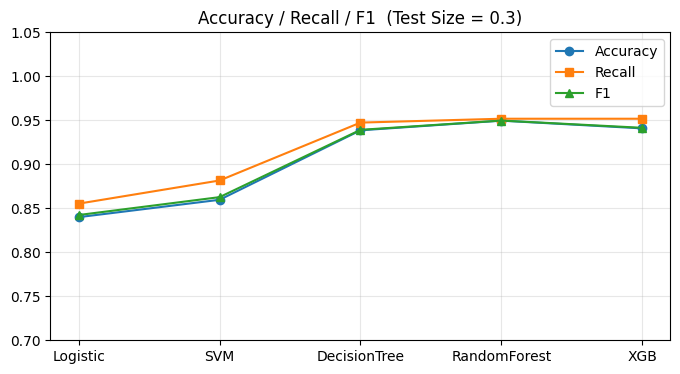

C:\Users\Bharat Singh\AppData\Local\Temp\ipykernel_13672\858478114.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=step_df, x="Model", y="Score", palette="viridis")


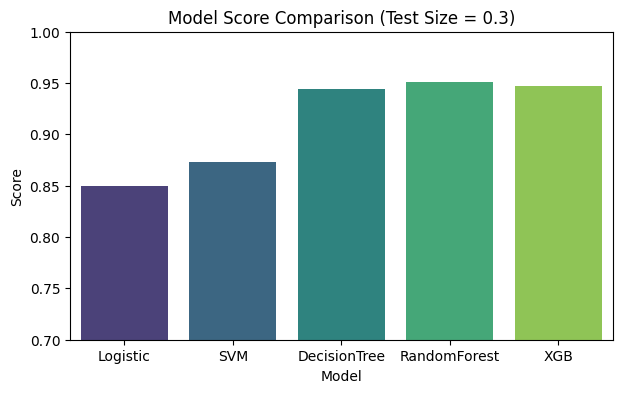

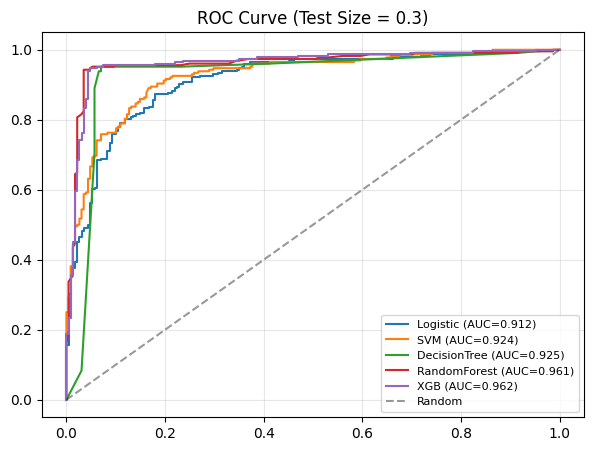

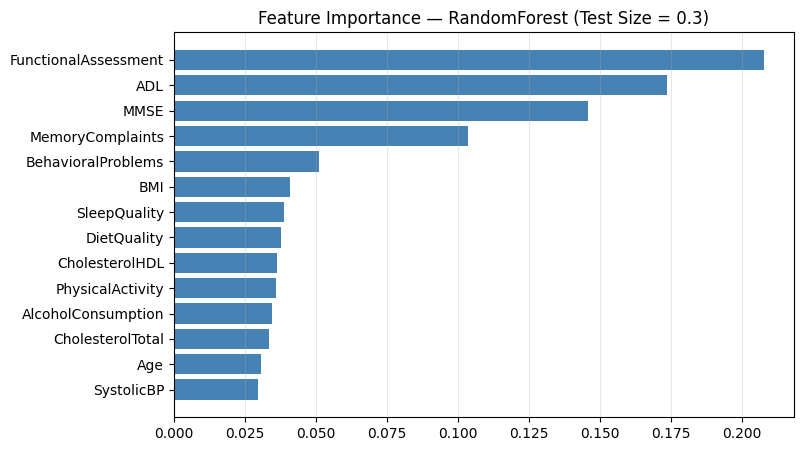


All results:


,TestSize,Model,Accuracy,Recall,F1,Score
13,0.30,RandomForest,0.949561,0.951754,0.949672,0.950888
9,0.25,XGB,0.939474,0.952632,0.940260,0.947447
14,0.30,XGB,0.940789,0.951754,0.941432,0.947433
12,0.30,DecisionTree,0.938596,0.947368,0.939130,0.943913
7,0.25,DecisionTree,0.934211,0.942105,0.934726,0.938999
8,0.25,RandomForest,0.939474,0.936842,0.939314,0.937879
3,0.20,RandomForest,0.930921,0.934211,0.931148,0.932917
4,0.20,XGB,0.917763,0.940789,0.919614,0.931764
2,0.20,DecisionTree,0.921053,0.934211,0.922078,0.929050
1,0.20,SVM,0.851974,0.907895,0.859813,0.886310


In [7]:
all_results = []

for test_size in test_sizes:

    print(f"\n{'='*35}")
    print(f"  TEST SIZE: {test_size}")
    print(f"{'='*35}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42)

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

    step_results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc   = accuracy_score(y_test, y_pred)
        rec   = recall_score(y_test, y_pred)
        f1    = f1_score(y_test, y_pred)
        score = 0.6 * rec + 0.3 * acc + 0.1 * f1

        step_results.append({"Model": name, "Accuracy": acc,
                              "Recall": rec, "F1": f1, "Score": score})
        all_results.append({"TestSize": test_size, "Model": name,
                             "Accuracy": acc, "Recall": rec, "F1": f1, "Score": score})

        print(f"  {name:15s}  Acc={acc:.4f}  Rec={rec:.4f}  F1={f1:.4f}")

    step_df = pd.DataFrame(step_results)
    display(step_df.style.highlight_max(
        subset=["Accuracy","Recall","F1","Score"], color="green"))

    # Accuracy / Recall / F1
    plt.figure(figsize=(8, 4))
    plt.plot(step_df["Model"], step_df["Accuracy"], marker="o", label="Accuracy")
    plt.plot(step_df["Model"], step_df["Recall"],   marker="s", label="Recall")
    plt.plot(step_df["Model"], step_df["F1"],       marker="^", label="F1")
    plt.title(f"Accuracy / Recall / F1  (Test Size = {test_size})")
    plt.ylim(0.7, 1.05); plt.legend(); plt.grid(alpha=0.3)
    plt.savefig(os.path.join(PLOT_DIR, f"acc_vs_rec_{test_size}.png"), dpi=120)
    plt.show(); plt.close()

    # Score bar
    plt.figure(figsize=(7, 4))
    sns.barplot(data=step_df, x="Model", y="Score", palette="viridis")
    plt.title(f"Model Score Comparison (Test Size = {test_size})")
    plt.ylim(0.7, 1.0)
    plt.savefig(os.path.join(PLOT_DIR, f"bar_{test_size}.png"), dpi=120)
    plt.show(); plt.close()

    # ROC Curve
    plt.figure(figsize=(7, 5))
    for name, model in models.items():
        y_prob_all = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob_all)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0,1],[0,1],"k--", alpha=0.4, label="Random")
    plt.legend(fontsize=8); plt.grid(alpha=0.3)
    plt.title(f"ROC Curve (Test Size = {test_size})")
    plt.savefig(os.path.join(PLOT_DIR, f"roc_{test_size}.png"), dpi=120)
    plt.show(); plt.close()

    # Feature Importance (RF)
    rf_model = models["RandomForest"]
    feat_df = pd.DataFrame({
        "Feature":    X.columns,
        "Importance": rf_model.feature_importances_
    }).sort_values("Importance", ascending=False)
    plt.figure(figsize=(8, 5))
    plt.barh(feat_df["Feature"], feat_df["Importance"], color="steelblue")
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance — RandomForest (Test Size = {test_size})")
    plt.grid(axis="x", alpha=0.3)
    plt.savefig(os.path.join(PLOT_DIR, f"feature_{test_size}.png"),
                dpi=120, bbox_inches="tight")
    plt.show(); plt.close()

results_df = pd.DataFrame(all_results)
print("\nAll results:")
display(results_df.sort_values("Score", ascending=False))


In [8]:
best_models = {}
for t in test_sizes:
    subset   = results_df[results_df["TestSize"] == t]
    best_row = subset.loc[subset["Score"].idxmax()]
    best_models[t] = best_row
    print(f"Best for test_size={t}: {best_row['Model']}  (Score={best_row['Score']:.4f})")

final_best_row   = results_df.loc[results_df["Score"].idxmax()]
final_test_size  = final_best_row["TestSize"]
final_model_name = final_best_row["Model"]

print(f"\nFINAL BEST → Model: {final_model_name}  |  Test Size: {final_test_size}")
print(f"  Accuracy : {final_best_row['Accuracy']:.4f}")
print(f"  Recall   : {final_best_row['Recall']:.4f}")
print(f"  F1       : {final_best_row['F1']:.4f}")
print(f"  Score    : {final_best_row['Score']:.4f}")


Best for test_size=0.2: RandomForest  (Score=0.9329)
Best for test_size=0.25: XGB  (Score=0.9474)
Best for test_size=0.3: RandomForest  (Score=0.9509)

FINAL BEST → Model: RandomForest  |  Test Size: 0.3
  Accuracy : 0.9496
  Recall   : 0.9518
  F1       : 0.9497
  Score    : 0.9509


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=final_test_size, stratify=y, random_state=42)

scaler    = StandardScaler()
X_train   = scaler.fit_transform(X_train)
X_test    = scaler.transform(X_test)

final_model = models[final_model_name]
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
rauc = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print(f"{'='*35}")
print(f"  FINAL MODEL PERFORMANCE")
print(f"{'='*35}")
print(f"  Model    : {final_model_name}")
print(f"  Test Size: {final_test_size}")
print(f"  Accuracy : {acc:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC      : {rauc:.4f}")
print(f"{'='*35}")
print(f"\nConfusion Matrix:")
print(cm)


  FINAL MODEL PERFORMANCE
  Model    : RandomForest
  Test Size: 0.3
  Accuracy : 0.9496
  Recall   : 0.9518
  F1 Score : 0.9497
  AUC      : 0.9611

Confusion Matrix:
[[216  12]
 [ 11 217]]


Saved: c:\Users\Bharat Singh\Desktop\Alzheimers Prediction\notebook\plots\final_confusion_matrix.png


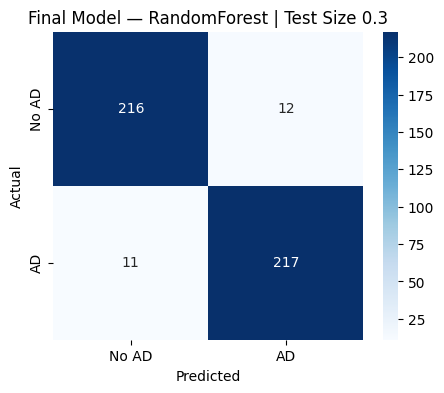

In [10]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No AD","AD"], yticklabels=["No AD","AD"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Final Model — {final_model_name} | Test Size {final_test_size}")
save_path = os.path.join(PLOT_DIR, "final_confusion_matrix.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print("Saved:", save_path)
plt.show(); plt.close()


Saved: c:\Users\Bharat Singh\Desktop\Alzheimers Prediction\notebook\plots\final_roc.png


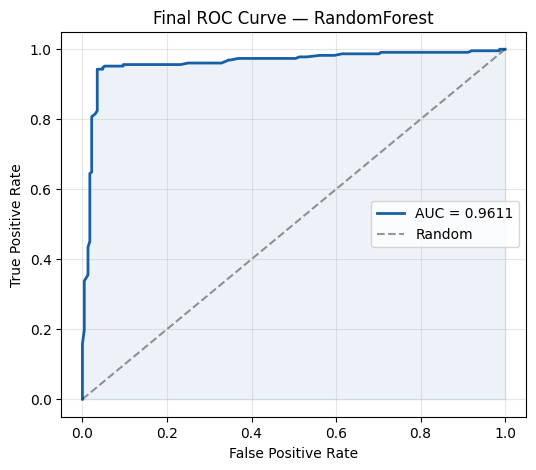

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val  = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.4f}", linewidth=2, color="#185FA5")
plt.fill_between(fpr, tpr, alpha=0.08, color="#185FA5")
plt.plot([0,1],[0,1],"k--", alpha=0.4, label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"Final ROC Curve — {final_model_name}")
plt.legend(); plt.grid(alpha=0.3)
save_path = os.path.join(PLOT_DIR, "final_roc.png")
plt.savefig(save_path, dpi=150)
print("Saved:", save_path)
plt.show(); plt.close()


Saved: c:\Users\Bharat Singh\Desktop\Alzheimers Prediction\notebook\plots\final_feature_importance.png


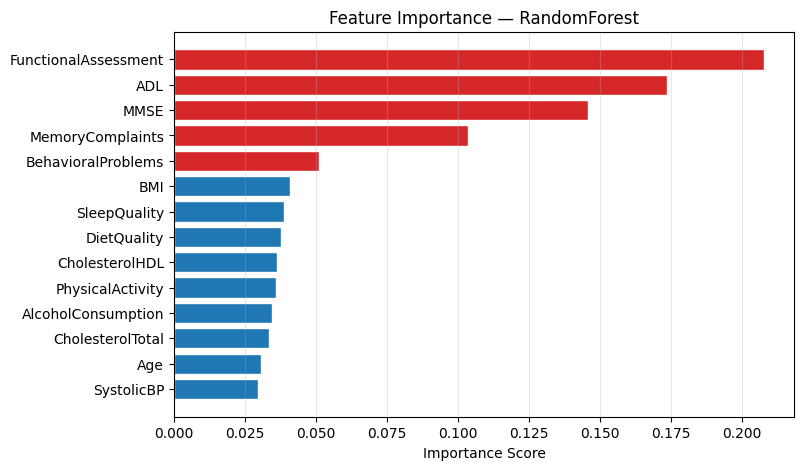

In [12]:
if hasattr(final_model, "feature_importances_"):
    feat_df = pd.DataFrame({
        "Feature":    X.columns,
        "Importance": final_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(8, 5))
    colors = ["#d62728" if i < 5 else "#1f77b4" for i in range(len(feat_df))]
    plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1],
             color=colors[::-1], edgecolor="white")
    plt.title(f"Feature Importance — {final_model_name}")
    plt.xlabel("Importance Score")
    plt.grid(axis="x", alpha=0.3)
    save_path = os.path.join(PLOT_DIR, "final_feature_importance.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show(); plt.close()


In [13]:
print(classification_report(y_test, y_pred,
      target_names=["No Alzheimer's", "Alzheimer's"]))


                precision    recall  f1-score   support

No Alzheimer's       0.95      0.95      0.95       228
   Alzheimer's       0.95      0.95      0.95       228

      accuracy                           0.95       456
     macro avg       0.95      0.95      0.95       456
  weighted avg       0.95      0.95      0.95       456

